In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import importlib
import numpy as np
import Functions as f
import Filtering as fil
importlib.reload(f)
importlib.reload(fil)

<module 'Filtering' from '/Users/james/Desktop/DATA3001/Filtering.py'>

In [3]:
# Load datasets

f12024 = pd.read_csv('UNSW F12024.csv')
left = pd.read_csv('f1sim-ref-left.csv')
right = pd.read_csv('f1sim-ref-right.csv')
line = pd.read_csv('f1sim-ref-line.csv')
turns = pd.read_csv('f1sim-ref-turns.csv')

/var/folders/ng/t1t6hw391s14957cdp0_2k5c0000gn/T/ipykernel_84573/956444696.py:3: DtypeWarning: Columns (70,71,73,74,82) have mixed types. Specify dtype option on import or set low_memory=False.
  f12024 = pd.read_csv('UNSW F12024.csv')


In [18]:
# Filter Data

df = f12024.copy()
df = fil.remove_nan(df)
df, left, right, line, turns = fil.filter_track_section(df, left, right, line, turns)
df = fil.keep_relevant_features(df)
df = fil.remove_nondriving_behaviour(df)

# Turn 1 and Turn 2
- The two critical turn points are given from the source data

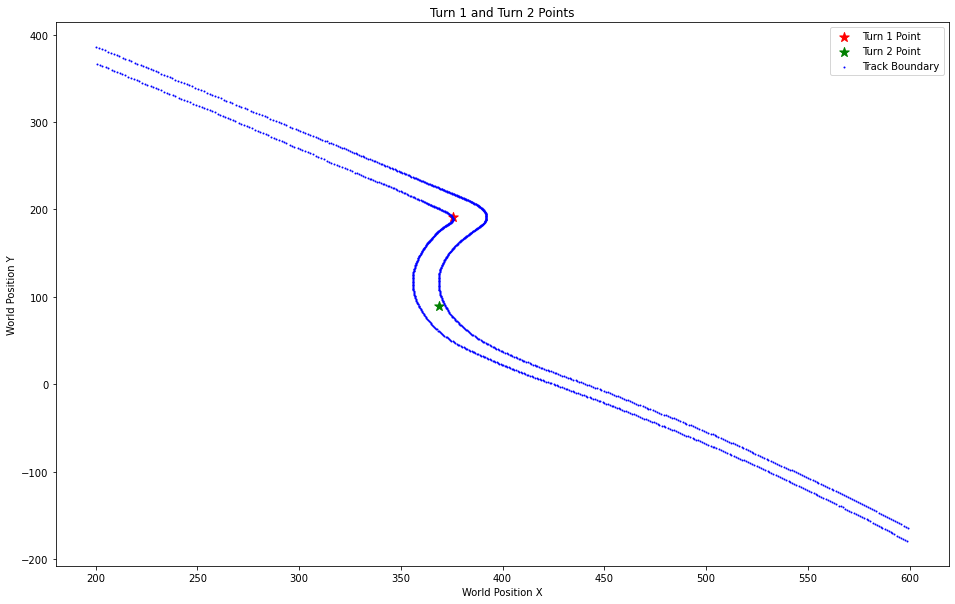

In [5]:
plt.figure(figsize=(16, 10))
plt.scatter(turns['APEX_X1'][0], turns['APEX_Y1'][0], color='red', s=100, marker='*', label="Turn 1 Point")
plt.scatter(turns['APEX_X1'][1], turns['APEX_Y1'][1], color='green', s=100, marker='*', label="Turn 2 Point")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Track Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')

plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title("Turn 1 and Turn 2 Points")
plt.legend()
plt.show()

# Braking Point before Turn 1
- There is no predefined braking point before turn 1 from the source data
- We define the braking point as the average position where most drivers take their first full brake before turn 1


In [6]:
# Define the region of interest
x_lower, x_upper = 325, 375  
y_lower, y_upper = 200, 400  

# Filter only rows within the region and with full brake
turn1_region = df[
    df['M_WORLDPOSITIONX_1'].between(x_lower, x_upper) &
    df['M_WORLDPOSITIONY_1'].between(y_lower, y_upper) &
    (df['M_BRAKE_1'] == 1)
]

group_cols = ['SESSION_GUID', 'M_CURRENTLAPNUM']

first_max_brake = (
    turn1_region
    .sort_values(group_cols)
    .groupby(group_cols, as_index=False)
    .head(1)
    .reset_index(drop=True)
)

avgx = first_max_brake['M_WORLDPOSITIONX_1'].mean()
avgy = first_max_brake['M_WORLDPOSITIONY_1'].mean()

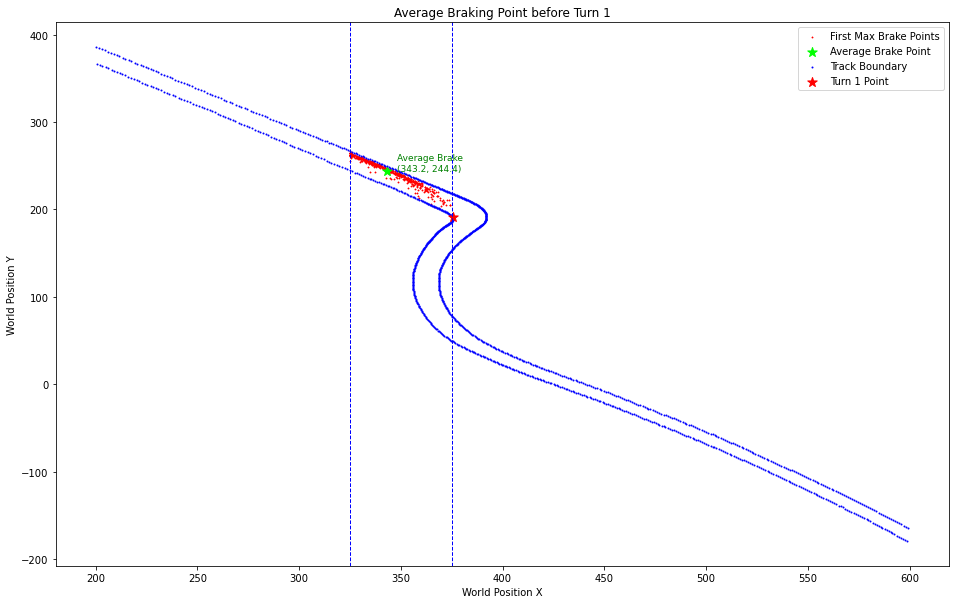

In [10]:
plt.figure(figsize=(16, 10))
plt.scatter(first_max_brake['M_WORLDPOSITIONX_1'], first_max_brake['M_WORLDPOSITIONY_1'],
            color='red', s=1, marker = '*', label="First Max Brake Points")
plt.scatter(avgx, avgy, color='lime', s=100, marker='*', label='Average Brake Point')
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Track Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')
plt.scatter(turns['APEX_X1'][0], turns['APEX_Y1'][0], color='red', s=100, marker='*', label="Turn 1 Point")


plt.axvline(x_lower, color='blue', linestyle='--', linewidth=1)
plt.axvline(x_upper, color='blue', linestyle='--', linewidth=1)
plt.text(avgx + 5, avgy, f"Average Brake\n({avgx:.1f}, {avgy:.1f})",
         fontsize=9, color='green')

plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title("Average Braking Point before Turn 1")
plt.legend()
plt.show()

# Midpoint between Turn 1 and Turn 2
- An additional critical point we define as the (rough) midpoint between the source data's turn 1 and turn 2

In [11]:
# Turn 1 and Turn 2 coordinates
t1_x, t1_y = turns['APEX_X1'].iloc[0], turns['APEX_Y1'].iloc[0]
t2_x, t2_y = turns['APEX_X1'].iloc[1], turns['APEX_Y1'].iloc[1]

# Compute midpoint
midx = (t1_x + t2_x) / 2 - 6.7
midy = (t1_y + t2_y) / 2

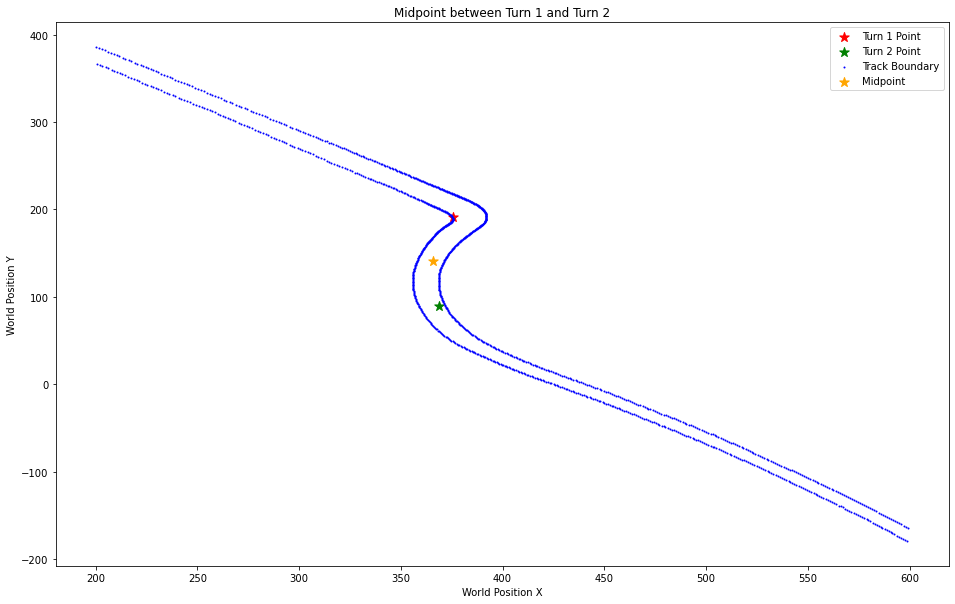

In [12]:
plt.figure(figsize=(16, 10))
plt.scatter(turns['APEX_X1'][0], turns['APEX_Y1'][0], color='red', s=100, marker='*', label="Turn 1 Point")
plt.scatter(turns['APEX_X1'][1], turns['APEX_Y1'][1], color='green', s=100, marker='*', label="Turn 2 Point")
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Track Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')
plt.scatter(midx, midy, color='orange', s=100, marker='*', label='Midpoint')


plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title("Midpoint between Turn 1 and Turn 2")
plt.legend()
plt.show()

# Critical Points 
4 Final Critical Points:
- Braking Point
- Turn 1 Point
- Mid Point
- Turn 2 Point

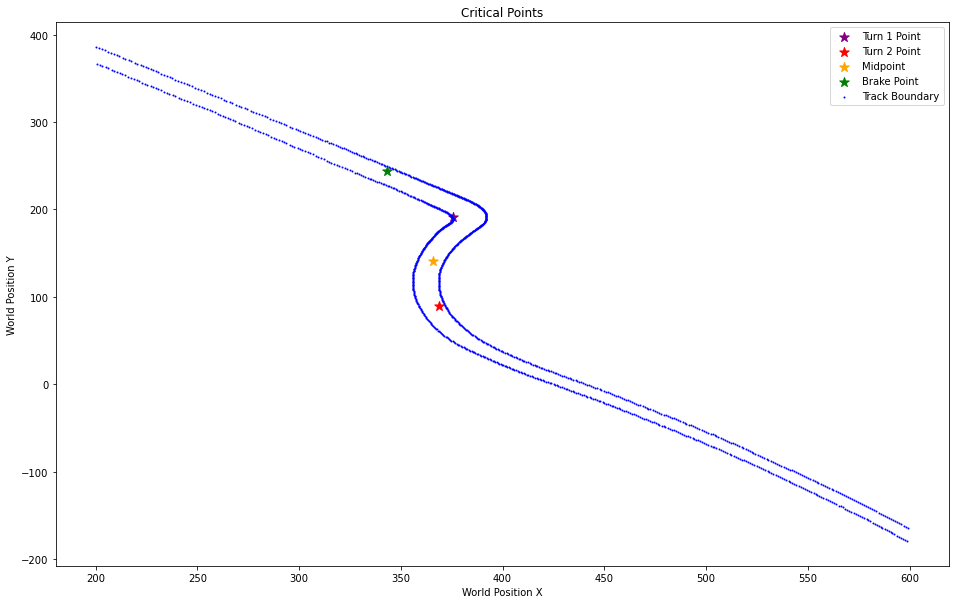

In [13]:
plt.figure(figsize=(16, 10))
plt.scatter(turns['APEX_X1'][0], turns['APEX_Y1'][0], color='purple', s=100, marker='*', label="Turn 1 Point")
plt.scatter(turns['APEX_X1'][1], turns['APEX_Y1'][1], color='red', s=100, marker='*', label="Turn 2 Point")
plt.scatter(midx, midy, color='orange', s=100, marker='*', label='Midpoint')
plt.scatter(avgx, avgy, color='green', s=100, marker='*', label='Brake Point')
plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label="Track Boundary")
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')



plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title("Critical Points")
plt.legend()
plt.show()

# Critical Points to Critical Lines

- We define the critical lines by taking finding the closest point from the left and right boundary and connecting them

In [14]:
turn2x, turn2y = 368.93, 90.000
ref_point2= turn2x, turn2y

cross2 = f.closest_barrier_points(turn2x, turn2y, left, right)
left_point2= cross2["left_point"]
right_point2= cross2["right_point"]

turn1x, turn1y = 375.57, 191.519
ref_point1 = turn1x, turn1y

cross1 = f.closest_barrier_points(turn1x, turn1y, left, right)
left_point1 = cross1["left_point"]
right_point1 = cross1["right_point"]

ref_pointm = midx, midy

crossm = f.closest_barrier_points(midx, midy, left, right)
left_pointm = crossm["left_point"]
right_pointm = crossm["right_point"]

ref_pointb = avgx, avgy

crossb = f.closest_barrier_points(avgx, avgy, left, right)
left_pointb = crossb["left_point"]
right_pointb = crossb["right_point"]

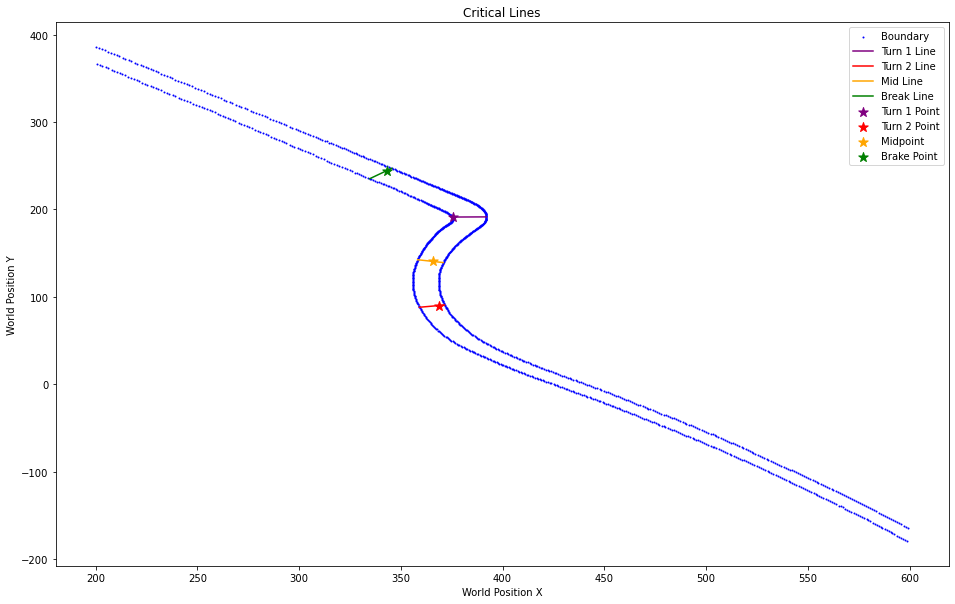

In [15]:
plt.figure(figsize=(16, 10))

plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label='Boundary')
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')
plt.plot([cross1["left_point"][0], cross1["right_point"][0]], [cross1["left_point"][1], cross1["right_point"][1]], color='purple', label='Turn 1 Line')
plt.plot([cross2["left_point"][0], cross2["right_point"][0]], [cross2["left_point"][1], cross2["right_point"][1]], color='red', label='Turn 2 Line')
plt.plot([crossm["left_point"][0], crossm["right_point"][0]], [crossm["left_point"][1], crossm["right_point"][1]], color='orange', label='Mid Line')
plt.plot([crossb["left_point"][0], crossb["right_point"][0]], [crossb["left_point"][1], crossb["right_point"][1]], color='green', label='Break Line')

plt.scatter(turns['APEX_X1'][0], turns['APEX_Y1'][0], color='purple', s=100, marker='*', label="Turn 1 Point")
plt.scatter(turns['APEX_X1'][1], turns['APEX_Y1'][1], color='red', s=100, marker='*', label="Turn 2 Point")
plt.scatter(midx, midy, color='orange', s=100, marker='*', label='Midpoint')
plt.scatter(avgx, avgy, color='green', s=100, marker='*', label='Brake Point')

plt.legend()

plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title(f"Critical Lines")

plt.show()

In [19]:
df2 = df.copy()
df2 = fil.dedupe_xyz(df2)
df2 = fil.remove_incomplete_laps(df2)

In [20]:
df2

,SESSION_GUID,M_TIMESTAMP,M_CURRENTLAPNUM,M_SPEED_1,M_THROTTLE_1,M_STEER_1,M_BRAKE_1,M_GEAR_1,M_CURRENTLAPINVALID_1,M_WORLDPOSITIONX_1,M_WORLDPOSITIONY_1,M_WORLDPOSITIONZ_1
0,1BF21BECE1C29DBFE0631718000AACA5,1719613619244,1,302.0,1.0,0.000000,0.0,8.0,0,211.493089,372.398511,2.420495
1,1BF21BECE1C29DBFE0631718000AACA5,1719613619244,1,302.0,1.0,0.000000,0.0,8.0,0,212.219234,371.710202,2.416685
2,1BF21BECE1C29DBFE0631718000AACA5,1719613619244,1,303.0,1.0,0.000000,0.0,8.0,0,212.945403,371.021913,2.412226
3,1BF21BECE1C29DBFE0631718000AACA5,1719613619244,1,303.0,1.0,0.000000,0.0,8.0,0,213.671602,370.333650,2.406970
4,1BF21BECE1C29DBFE0631718000AACA5,1719613619244,1,303.0,1.0,0.000000,0.0,8.0,0,214.397801,369.645388,2.401713
...,...,...,...,...,...,...,...,...,...,...,...,...
407249,3068C4A99FD74FD8E0631218000A9C50,1742072575774,2,291.0,1.0,0.025560,0.0,8.0,0,579.873322,-151.558442,3.231781
407250,3068C4A99FD74FD8E0631218000A9C50,1742072575774,2,291.0,1.0,0.024675,0.0,8.0,0,580.532603,-152.309006,3.229759
407251,3068C4A99FD74FD8E0631218000A9C50,1742072575774,2,291.0,1.0,0.023790,0.0,8.0,0,581.191883,-153.059569,3.227736
407252,3068C4A99FD74FD8E0631218000A9C50,1742072575774,2,291.0,1.0,0.022905,0.0,8.0,0,581.851164,-153.810132,3.225714


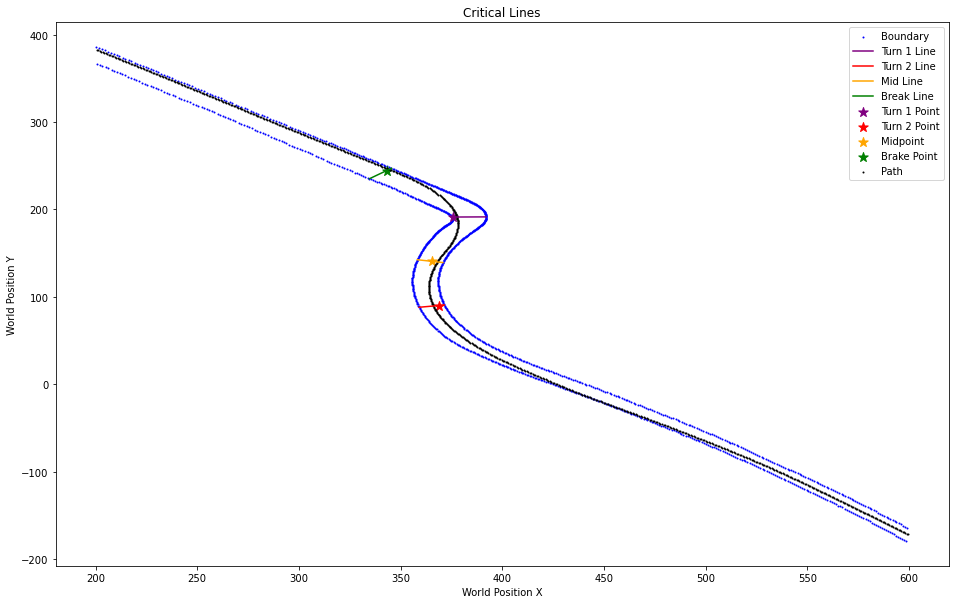

In [21]:
example_session = '1BF21BECE1C29DBFE0631718000AACA5'
example_lap = 1
example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]



plt.figure(figsize=(16, 10))

plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label='Boundary')
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')
plt.plot([cross1["left_point"][0], cross1["right_point"][0]], [cross1["left_point"][1], cross1["right_point"][1]], color='purple', label='Turn 1 Line')
plt.plot([cross2["left_point"][0], cross2["right_point"][0]], [cross2["left_point"][1], cross2["right_point"][1]], color='red', label='Turn 2 Line')
plt.plot([crossm["left_point"][0], crossm["right_point"][0]], [crossm["left_point"][1], crossm["right_point"][1]], color='orange', label='Mid Line')
plt.plot([crossb["left_point"][0], crossb["right_point"][0]], [crossb["left_point"][1], crossb["right_point"][1]], color='green', label='Break Line')

plt.scatter(turns['APEX_X1'][0], turns['APEX_Y1'][0], color='purple', s=100, marker='*', label="Turn 1 Point")
plt.scatter(turns['APEX_X1'][1], turns['APEX_Y1'][1], color='red', s=100, marker='*', label="Turn 2 Point")
plt.scatter(midx, midy, color='orange', s=100, marker='*', label='Midpoint')
plt.scatter(avgx, avgy, color='green', s=100, marker='*', label='Brake Point')

plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")

plt.legend()

plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title(f"Critical Lines")

plt.show()

In [22]:
turn1 = pd.read_csv('turn_1_stats.csv')
turn2 = pd.read_csv('turn_2_stats.csv')
brake = pd.read_csv('brake_point_stats.csv')
mid = pd.read_csv('mid_point_stats.csv')

In [31]:
turn1e = turn1[(turn1["SESSION_GUID"] == example_session) & (turn1['M_CURRENTLAPNUM'] == example_lap)]
turn2e = turn2[(turn2["SESSION_GUID"] == example_session) & (turn2['M_CURRENTLAPNUM'] == example_lap)]
mide = mid[(mid["SESSION_GUID"] == example_session) & (mid['M_CURRENTLAPNUM'] == example_lap)]
brakee = brake[(brake["SESSION_GUID"] == example_session) & (brake['M_CURRENTLAPNUM'] == example_lap)]

In [32]:
turn1e

,SESSION_GUID,M_CURRENTLAPNUM,x_cross,y_cross,z_cross,Speed,alpha,Throttle,Brake,Steer,Gear
532,3068C4A99FD74FD8E0631218000A9C50,2,371.999026,191.478532,2.3799,172.363324,0.186851,0.339751,0.49547,0.158258,4.0


In [33]:
turn2e

,SESSION_GUID,M_CURRENTLAPNUM,x_cross,y_cross,z_cross,Speed,alpha,Throttle,Brake,Steer,Gear
532,3068C4A99FD74FD8E0631218000A9C50,2,374.089648,91.061485,2.734591,206.722006,0.585063,1.0,0.0,-0.071324,5.0


In [34]:
mide

,SESSION_GUID,M_CURRENTLAPNUM,x_cross,y_cross,z_cross,Speed,alpha,Throttle,Brake,Steer,Gear
532,3068C4A99FD74FD8E0631218000A9C50,2,369.200552,139.814484,2.553342,186.221297,0.956739,0.964873,0.02636,-0.001877,4.0


In [35]:
brakee

,SESSION_GUID,M_CURRENTLAPNUM,x_cross,y_cross,z_cross,Speed,alpha,Throttle,Brake,Steer,Gear
532,3068C4A99FD74FD8E0631218000A9C50,2,341.920391,242.987609,2.188371,251.728738,0.405204,0.0,1.0,0.077365,8.0


ValueError: x and y must be the same size

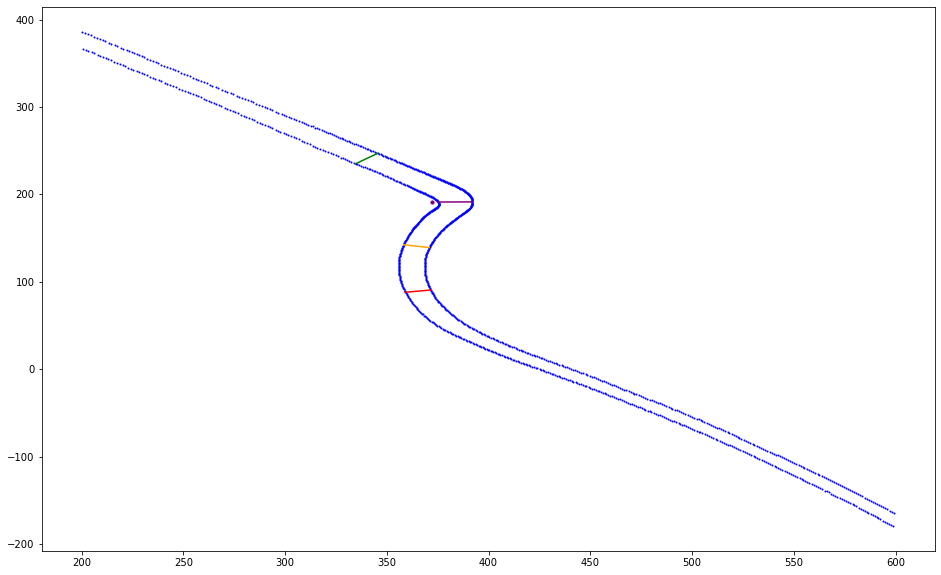

In [30]:
example_session = '3068C4A99FD74FD8E0631218000A9C50'
example_lap = 2
example = df[(df["SESSION_GUID"] == example_session) & (df['M_CURRENTLAPNUM'] == example_lap)]
turn1e = turn1[(turn1["SESSION_GUID"] == example_session) & (turn1['M_CURRENTLAPNUM'] == example_lap)]
turn2e = turn2[(turn2["SESSION_GUID"] == example_session) & (turn2['M_CURRENTLAPNUM'] == example_lap)]
mide = mid[(mid["SESSION_GUID"] == example_session) & (mid['M_CURRENTLAPNUM'] == example_lap)]
brakee = brake[(brake["SESSION_GUID"] == example_session) & (brake['M_CURRENTLAPNUM'] == example_lap)]


plt.figure(figsize=(16, 10))

plt.scatter(left['WORLDPOSX'], left['WORLDPOSY'], s=1, color = 'blue', label='Boundary')
plt.scatter(right['WORLDPOSX'], right['WORLDPOSY'], s=1, color = 'blue')
plt.plot([cross1["left_point"][0], cross1["right_point"][0]], [cross1["left_point"][1], cross1["right_point"][1]], color='purple', label='Turn 1 Line')
plt.plot([cross2["left_point"][0], cross2["right_point"][0]], [cross2["left_point"][1], cross2["right_point"][1]], color='red', label='Turn 2 Line')
plt.plot([crossm["left_point"][0], crossm["right_point"][0]], [crossm["left_point"][1], crossm["right_point"][1]], color='orange', label='Mid Line')
plt.plot([crossb["left_point"][0], crossb["right_point"][0]], [crossb["left_point"][1], crossb["right_point"][1]], color='green', label='Break Line')

# plt.scatter(turns['APEX_X1'][0], turns['APEX_Y1'][0], color='purple', s=100, marker='*', label="Turn 1 Point")
# plt.scatter(turns['APEX_X1'][1], turns['APEX_Y1'][1], color='red', s=100, marker='*', label="Turn 2 Point")
# plt.scatter(midx, midy, color='orange', s=100, marker='*', label='Midpoint')
# plt.scatter(avgx, avgy, color='green', s=100, marker='*', label='Brake Point')


plt.scatter(turn1e['x_cross'], turn1e['y_cross'], color="purple", s=10, label="Car path")
# plt.scatter(turn2e['x_cross'], turn2['y_cross'], color="black", s=0.1, label="Car path")
plt.scatter(mide['x_cross'], mid['y_cross'], color="black", s=0.1, label="Car path")
plt.scatter(brakee['x_cross'], brake['y_cross'], color="black", s=0.1, label="Car path")

plt.scatter(example['M_WORLDPOSITIONX_1'], example['M_WORLDPOSITIONY_1'], color="black", s=1, label="Path")

plt.legend()

plt.xlabel("World Position X")
plt.ylabel("World Position Y")
plt.title(f"Critical Lines")

plt.show()